# 02 — Replicación de Quabis *et al.* (2000) con `vecdiff`

El cuaderno 01 replicó el artículo integrando directamente las fórmulas de
Richards–Wolf. Aquí **el motor numérico es el del paquete de la tesis**:

1. La sustitución $u = \sin\theta$ convierte cada integral de Debye–Wolf en
   una transformada de Hankel
   $I(s) = \int_0^{\mathrm{NA}} f(u)\, J_m(2\pi s u)\, u\, du$ — exactamente
   el objeto que `vecdiff.hankel.HankelTransform` evalúa. La lente
   aplanática entra como una **pupila generalizada** $f(u)$, igual que el
   dioptrio estigmático entra en la tesis a través de $t_p, t_s$.
2. $E_z$ **no** se toma de la fórmula cerrada del artículo: se reconstruye
   desde las componentes transversales con
   `vecdiff.longitudinal.generate_Ez_cartesian` (espectro angular, la
   transversalidad de Maxwell) y se **valida** contra el canal
   $I_1$/$I_z$ de Richards–Wolf.

El propagador de dioptrio (`propagate_to_focal_plane_through_diopter`) no
se usa: ese modelo lleva la apodización $t_p, t_s$ de Fresnel del dioptrio
estigmático; su comparación con el régimen de Quabis es el cuaderno 03.

## Pupilas generalizadas aplanáticas (con $c = \sqrt{1-u^2} = \cos\theta$)

| canal | orden $m$ | $f(u)$ | contenido |
| --- | --- | --- | --- |
| $I_0$ | 0 | $\ell\,(1+c)/\sqrt{c}$ | lineal, copolar |
| $I_1$ | 1 | $\ell\, u/\sqrt{c}$ | lineal, longitudinal |
| $I_2$ | 2 | $\ell\,(1-c)/\sqrt{c}$ | lineal, cruzada |
| $I_r$ | 1 | $\ell\,\sqrt{c}$ | dona, transversal |
| $I_z$ | 0 | $\ell\, u/\sqrt{c}$ | dona, longitudinal |
| escalar | 0 | $\ell/\sqrt{c}$ | referencia sin factores vectoriales |

En NA $=1$ el borde $u = 1$ ($c = 0$) es una singularidad **integrable**
($\propto (1-u)^{-1/4}$): se muestrea con $\theta$ uniforme —que concentra
los puntos allí— y se anula la última muestra, cuyo intervalo en $u$ tiene
medida $\sim d\theta^2/2$.

La referencia **escalar** es la misma apodización e iluminación con el
campo tratado como amplitud escalar (canal $J_0$ sin factores vectoriales):
el análogo directo del límite $t_s = t_p = 1$ de la tesis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

from vecdiff.hankel import HankelTransform
from vecdiff.longitudinal import generate_Ez_cartesian

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

gamma_gauss = np.log(10.0) / 2.0
T_dough = brentq(lambda T: np.exp(-T) * (1.0 + T) - 0.1, 1.0, 20.0)
gamma_dough = T_dough / 2.0

CHANNELS = {
    "I0": (0, lambda u, c: 1.0 + c),
    "I1": (1, lambda u, c: u),
    "I2": (2, lambda u, c: 1.0 - c),
    "Ir": (1, lambda u, c: c),
    "Iz": (0, lambda u, c: u),
    "Iesc": (0, lambda u, c: np.ones_like(u)),
}


def debye_profiles(NA, ell, channels, n_theta=3000, s_max=3.0, n_s=1501):
    """Perfiles focales sobre s = rho/lambda, vía la Hankel de vecdiff."""
    theta = np.linspace(0.0, np.arcsin(NA), n_theta)
    u, c = np.sin(theta), np.cos(theta)
    inv_sqrt_c = np.zeros_like(c)
    np.divide(1.0, np.sqrt(c), out=inv_sqrt_c, where=c > 1e-12)
    base = ell(u / NA) * inv_sqrt_c

    s = np.linspace(0.0, s_max, n_s)
    q = 2.0 * np.pi * s
    out = {"s": s}
    for ch in channels:
        order, weight = CHANNELS[ch]
        out[ch] = HankelTransform.transform_array(order, u, base * weight(u, c), q).real
    return out


def linear_map(p, half=2.0, n=801):
    """|E|^2 en el plano focal, polarizacion incidente paralela a y."""
    x = np.linspace(-half, half, n)
    xx, yy = np.meshgrid(x, x)
    rho, phi = np.hypot(xx, yy), np.arctan2(yy, xx)
    I0 = np.interp(rho, p["s"], p["I0"])
    I1 = np.interp(rho, p["s"], p["I1"])
    I2 = np.interp(rho, p["s"], p["I2"])
    I = ((I0 - I2 * np.cos(2 * phi)) ** 2 + (I2 * np.sin(2 * phi)) ** 2
         + 4.0 * (I1 * np.sin(phi)) ** 2)
    return x, I


def radial_map(p, half=2.0, n=801):
    x = np.linspace(-half, half, n)
    xx, yy = np.meshgrid(x, x)
    rho = np.hypot(xx, yy)
    I = np.interp(rho, p["s"], p["Ir"] ** 2 + p["Iz"] ** 2)
    return x, I


rho_g = np.linspace(0.0, 3.0, 4000)
phi_g = np.linspace(0.0, 2.0 * np.pi, 1440, endpoint=False)
d_rho, d_phi = rho_g[1] - rho_g[0], phi_g[1] - phi_g[0]
dA = rho_g[:, None] * d_rho * d_phi


def area_linear(p):
    I0 = np.interp(rho_g, p["s"], p["I0"])[:, None]
    I1 = np.interp(rho_g, p["s"], p["I1"])[:, None]
    I2 = np.interp(rho_g, p["s"], p["I2"])[:, None]
    c2, s2, c1 = (f(phi_g)[None, :] for f in
                  (lambda x: np.cos(2 * x), lambda x: np.sin(2 * x), np.cos))
    I = (I0 + I2 * c2) ** 2 + (I2 * s2) ** 2 + 4.0 * (I1 * c1) ** 2
    return float(np.sum(dA * (I > 0.5 * I.max())))


def areas_radial(p):
    """(area total, area solo Ez) por cuadratura radial exacta."""
    rho = np.linspace(0.0, 3.0, 20000)
    Ir = np.interp(rho, p["s"], p["Ir"])
    Iz = np.interp(rho, p["s"], p["Iz"])
    out = []
    for I in (Ir**2 + Iz**2, Iz**2):
        mask = I > 0.5 * I.max()
        out.append(float(2.0 * np.pi * np.trapezoid(rho * mask, rho)))
    return out


def half_crossing(s, I, level):
    """Primer radio donde el perfil I cae por debajo de `level`."""
    idx = int(np.argmax(I < level))
    if idx == 0:
        return np.nan
    f = (I[idx - 1] - level) / (I[idx - 1] - I[idx])
    return float(s[idx - 1] + f * (s[idx] - s[idx - 1]))

## Tabla 1 vía `vecdiff`

Mismas integrales que el cuaderno 01 (allí: cuadratura directa en $\theta$;
aquí: Hankel de `vecdiff` en $u$ con Simpson no uniforme): las áreas deben
coincidir entre sí y con las publicadas.

In [2]:
illum = {
    "lineal gaussiana": ("linear", lambda v: np.exp(-gamma_gauss * v**2)),
    "lineal homogénea": ("linear", lambda v: np.ones_like(v)),
    "lineal homogénea + anular": ("linear", lambda v: 1.0 * (v >= 0.9)),
    "dona radial (total)": ("radial", lambda v: v * np.exp(-gamma_dough * v**2)),
    "dona radial (solo Ez)": None,
    "dona + anular (total)": ("radial",
                              lambda v: v * np.exp(-gamma_dough * v**2) * (v >= 0.9)),
    "dona + anular (solo Ez)": None,
}
published = {
    "lineal gaussiana": [0.555, 0.441, 0.360, 0.311],
    "lineal homogénea": [0.460, 0.370, 0.306, 0.277],
    "lineal homogénea + anular": [0.277, 0.249, 0.250, 0.330],
    "dona radial (total)": [2.681, 1.533, 0.652, 0.260],
    "dona radial (solo Ez)": [0.373, 0.275, 0.212, 0.160],
    "dona + anular (total)": [0.642, 0.291, 0.166, 0.110],
    "dona + anular (solo Ez)": [0.225, 0.166, 0.135, 0.107],
}
NAs = [0.7, 0.8, 0.9, 1.0]

computed = {name: [] for name in illum}
profiles = {}
for NA in NAs:
    for name, spec in illum.items():
        if spec is None:
            continue
        kind, ell = spec
        chans = ("I0", "I1", "I2") if kind == "linear" else ("Ir", "Iz")
        p = debye_profiles(NA, ell, chans)
        profiles[name, NA] = p
        if kind == "linear":
            computed[name].append(area_linear(p))
        else:
            a_tot, a_z = areas_radial(p)
            computed[name].append(a_tot)
            computed[name.replace("(total)", "(solo Ez)")].append(a_z)

print(f"{'iluminación':28s}" + "".join(f"   NA={NA:<10.1f}" for NA in NAs))
print(f"{'':28s}" + "   calc  (publ)" * 4)
worst = 0.0
for name in illum:
    row = ""
    for a_c, a_p in zip(computed[name], published[name]):
        rel = abs(a_c - a_p) / a_p
        worst = max(worst, rel)
        row += f"  {a_c:6.3f} ({a_p:.3f})"
    print(f"{name:28s}{row}")
print(f"\ndesviación relativa máxima contra la tabla publicada: {worst:.1%}")

iluminación                    NA=0.7          NA=0.8          NA=0.9          NA=1.0       
                               calc  (publ)   calc  (publ)   calc  (publ)   calc  (publ)
lineal gaussiana               0.567 (0.555)   0.447 (0.441)   0.368 (0.360)   0.318 (0.311)
lineal homogénea               0.465 (0.460)   0.372 (0.370)   0.314 (0.306)   0.288 (0.277)
lineal homogénea + anular      0.286 (0.277)   0.254 (0.249)   0.262 (0.250)   0.290 (0.330)
dona radial (total)            2.523 (2.681)   1.561 (1.533)   0.670 (0.652)   0.266 (0.260)
dona radial (solo Ez)          0.375 (0.373)   0.284 (0.275)   0.221 (0.212)   0.169 (0.160)
dona + anular (total)          0.660 (0.642)   0.300 (0.291)   0.175 (0.166)   0.116 (0.110)
dona + anular (solo Ez)        0.228 (0.225)   0.175 (0.166)   0.138 (0.135)   0.110 (0.107)

desviación relativa máxima contra la tabla publicada: 12.0%


## Componentes en el plano focal a NA $=0.9$, con $E_z$ de `vecdiff`

Los mapas transversales se muestrean sobre una ventana de $\pm 16\lambda$
(como en `examples/longitudinal_component.py`: la ventana FFT debe ser
grande para que las colas truncadas no «resuenen» de vuelta al centro),
con un **apodizado radial** $\cos^2$ entre $12\lambda$ y $15.5\lambda$ que
hace continua la extensión periódica del FFT — necesario porque las colas
del caso anular decaen apenas como $\rho^{-1/2}$ (sin apodizado el error
sube a $5\times 10^{-2}$). $E_z$ se reconstruye con
`generate_Ez_cartesian` y la validación compara $|E_z|$ contra el canal
de Richards–Wolf: $2\,I_1\sin\varphi$ (lineal $\parallel\hat{\mathbf y}$)
e $I_z$ (dona), sobre la zona central $\rho < 3\lambda$.

In [3]:
NA_dorn = 0.9
half_win, n_win = 16.0, 1024
x_win = np.linspace(-half_win, half_win, n_win)
xx, yy = np.meshgrid(x_win, x_win)
rho_w, phi_w = np.hypot(xx, yy), np.arctan2(yy, xx)
central = rho_w < 3.0
ramp = np.clip((15.5 - rho_w) / 3.5, 0.0, 1.0)
taper = np.where(rho_w <= 12.0, 1.0, np.cos(0.5 * np.pi * (1.0 - ramp)) ** 2)

wide = {}
for name in ("lineal homogénea", "dona radial (total)", "dona + anular (total)"):
    kind, ell = illum[name]
    chans = ("I0", "I1", "I2") if kind == "linear" else ("Ir", "Iz")
    wide[name] = debye_profiles(NA_dorn, ell, chans, s_max=half_win, n_s=3201)


def onto_window(p, ch):
    return np.interp(rho_w, p["s"], p[ch], right=0.0)


rows = {}

p = wide["lineal homogénea"]
Ey = (onto_window(p, "I0") - onto_window(p, "I2") * np.cos(2.0 * phi_w)) * taper
Ex = onto_window(p, "I2") * np.sin(2.0 * phi_w) * taper
Ez = generate_Ez_cartesian(Ex, Ey, (xx, yy), wavelength=1.0, n=1.0)
Ez_rw = 2.0 * onto_window(p, "I1") * np.sin(phi_w)
err = (np.max(np.abs(np.abs(Ez) - np.abs(Ez_rw))[central])
       / np.max(np.abs(Ez_rw)))
print(f"lineal   : max ||Ez_vecdiff| - |Ez_RW|| / max|Ez_RW| = {err:.2e}")
assert err < 2e-2
rows[r"lineal homogénea $\parallel\hat{\mathbf{y}}$"] = [
    (r"$|E_y|^2$ (copolar)", np.abs(Ey) ** 2),
    (r"$|E_x|^2$ (cruzada)", np.abs(Ex) ** 2),
    (r"$|E_z|^2$ (vecdiff)", np.abs(Ez) ** 2),
]

for name in ("dona radial (total)", "dona + anular (total)"):
    p = wide[name]
    Er = onto_window(p, "Ir") * taper
    Ex, Ey = Er * np.cos(phi_w), Er * np.sin(phi_w)
    Ez = generate_Ez_cartesian(Ex, Ey, (xx, yy), wavelength=1.0, n=1.0)
    Ez_rw = onto_window(p, "Iz")
    err = (np.max(np.abs(np.abs(Ez) - np.abs(Ez_rw))[central])
           / np.max(np.abs(Ez_rw)))
    print(f"{name.replace(' (total)', ''):9s}: "
          f"max ||Ez_vecdiff| - |Ez_RW|| / max|Ez_RW| = {err:.2e}")
    assert err < 2e-2
    rows[name.replace(" (total)", "")] = [
        (r"$|E_\perp|^2$", Er**2),
        (r"$|E_z|^2$ (vecdiff)", np.abs(Ez) ** 2),
        (r"total", Er**2 + np.abs(Ez) ** 2),
    ]

lineal   : max ||Ez_vecdiff| - |Ez_RW|| / max|Ez_RW| = 2.84e-03


dona radial: max ||Ez_vecdiff| - |Ez_RW|| / max|Ez_RW| = 1.73e-03


dona + anular: max ||Ez_vecdiff| - |Ez_RW|| / max|Ez_RW| = 1.44e-02


Cada panel está normalizado a su propio máximo para revelar la
estructura; el rótulo «máx» da su altura relativa al máximo de la fila.
En la fila lineal, la cruzada $|E_x|^2$ —cuatro lóbulos, canal $m=2$— y
la longitudinal $|E_z|^2$ —dos lóbulos sobre el eje de polarización,
canal $m=1$— son las mismas firmas vectoriales del capítulo III de la
tesis, aquí en el régimen de alta apertura del artículo. En las filas de
dona, $E_z$ pasa de llenar el centro (dona) a **dominar el total** (dona +
anular).

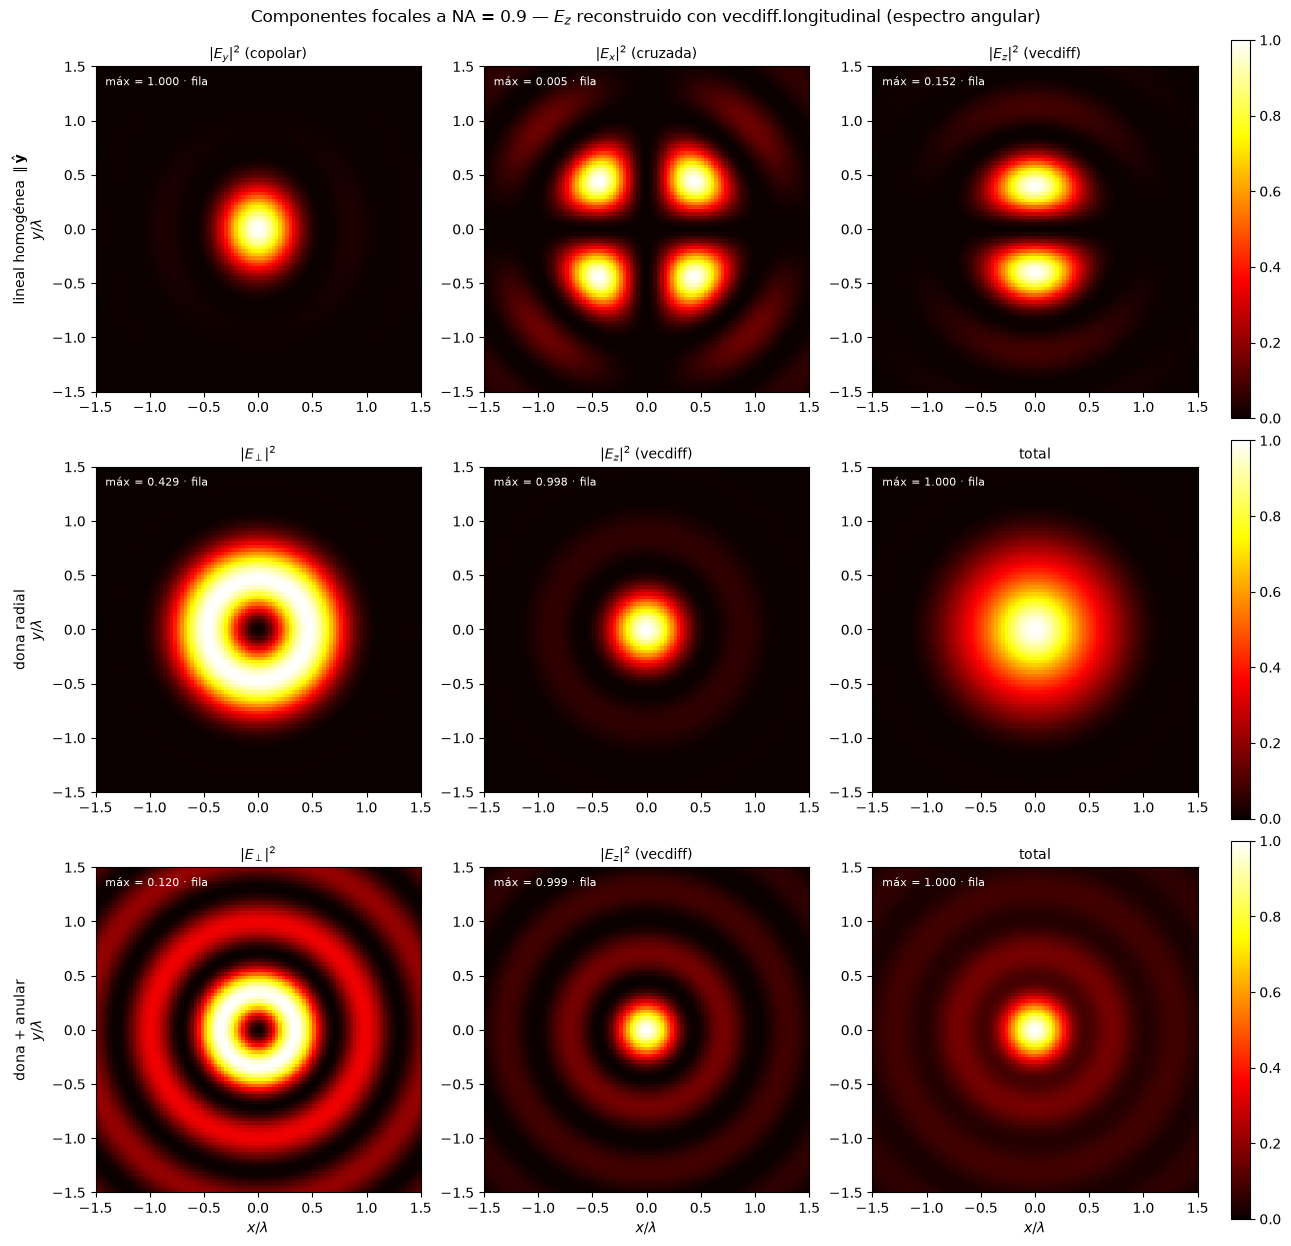

In [4]:
half_show = 1.5
sel = np.abs(x_win) <= half_show
ext = [-half_show, half_show] * 2

fig, axes = plt.subplots(3, 3, figsize=(12.8, 12.4), constrained_layout=True)
for (row_name, panels), ax_row in zip(rows.items(), axes):
    vmax = max(float(np.max(m[np.ix_(sel, sel)])) for _, m in panels)
    for ax, (title, m) in zip(ax_row, panels):
        sub = m[np.ix_(sel, sel)]
        im = ax.imshow(sub / sub.max(), extent=ext, origin="lower",
                       cmap="hot", vmin=0.0, vmax=1.0, aspect="equal")
        ax.set_title(title, fontsize=10)
        ax.text(0.03, 0.97, f"máx = {float(np.max(sub)) / vmax:.3f} · fila",
                transform=ax.transAxes, color="w", va="top", fontsize=8)
    fig.colorbar(im, ax=ax_row, fraction=0.02, pad=0.02)
    ax_row[0].set_ylabel(f"{row_name}\n" + r"$y/\lambda$")
for ax in axes[-1]:
    ax.set_xlabel(r"$x/\lambda$")
fig.suptitle("Componentes focales a NA = 0.9 — $E_z$ reconstruido con "
             "vecdiff.longitudinal (espectro angular)")
fig.savefig(out_dir / "02_componentes_NA09.png", dpi=200)
plt.show()

## Superposición de los spots: lineal, radial y escalar (NA $=0.9$)

Contornos de mitad de altura de los cuatro casos, a la misma escala: el
resumen geométrico del artículo en una sola figura. La dona + anular no
solo bate al caso lineal — su spot es menor incluso que la **predicción
escalar** de la misma apertura.

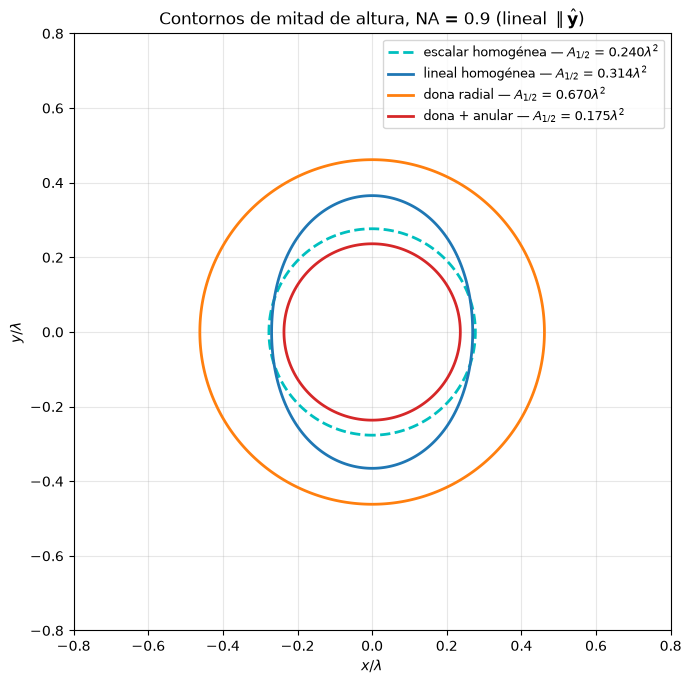

escalar homogénea: R_1/2 = 0.277 lambda,  A_1/2 = 0.240 lambda^2


In [5]:
p_esc = debye_profiles(NA_dorn, lambda v: np.ones_like(v), ("Iesc",),
                       s_max=1.5, n_s=1501)
I_esc_prof = p_esc["Iesc"] ** 2
R_esc = half_crossing(p_esc["s"], I_esc_prof / I_esc_prof.max(), 0.5)
A_esc = float(np.pi * R_esc**2)

half_o, n_o = 0.8, 801
x_o = np.linspace(-half_o, half_o, n_o)
xo, yo = np.meshgrid(x_o, x_o)
rho_o = np.hypot(xo, yo)

_, I_lin = linear_map(profiles["lineal homogénea", NA_dorn], half=half_o, n=n_o)
_, I_don = radial_map(profiles["dona radial (total)", NA_dorn], half=half_o, n=n_o)
_, I_anu = radial_map(profiles["dona + anular (total)", NA_dorn], half=half_o, n=n_o)
I_esc = np.interp(rho_o, p_esc["s"], p_esc["Iesc"]) ** 2

overlay = [
    ("escalar homogénea", I_esc, A_esc, "c", "--"),
    ("lineal homogénea", I_lin, computed["lineal homogénea"][2], "tab:blue", "-"),
    ("dona radial", I_don, computed["dona radial (total)"][2], "tab:orange", "-"),
    ("dona + anular", I_anu, computed["dona + anular (total)"][2], "tab:red", "-"),
]

fig, ax = plt.subplots(figsize=(6.8, 6.8), constrained_layout=True)
for name, I, area, color, ls in overlay:
    ax.contour(x_o, x_o, I / I.max(), levels=[0.5], colors=[color],
               linestyles=[ls], linewidths=2.0)
    ax.plot([], [], color=color, ls=ls, lw=2.0,
            label=rf"{name} — $A_{{1/2}}$ = {area:.3f}$\lambda^2$")
ax.set(aspect="equal", xlim=(-half_o, half_o), ylim=(-half_o, half_o),
       xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("Contornos de mitad de altura, NA = 0.9 "
             r"(lineal $\parallel\hat{\mathbf{y}}$)")
fig.savefig(out_dir / "02_solapamiento_spots_NA09.png", dpi=200)
plt.show()

print(f"escalar homogénea: R_1/2 = {R_esc:.3f} lambda,  "
      f"A_1/2 = {A_esc:.3f} lambda^2")

## Convergencia

In [6]:
kind, ell = illum["dona + anular (total)"]
for n_theta in (3000, 6000):
    p = debye_profiles(0.9, ell, ("Ir", "Iz"), n_theta=n_theta)
    a_tot, a_z = areas_radial(p)
    print(f"n_theta = {n_theta}:  area total = {a_tot:.4f}  solo Ez = {a_z:.4f}")

n_theta = 3000:  area total = 0.1755  solo Ez = 0.1379


n_theta = 6000:  area total = 0.1755  solo Ez = 0.1379


## Conclusiones

- La Tabla 1 calculada con la Hankel de `vecdiff` coincide con la del
  cuaderno 01 (misma física, distinta cuadratura) y con la publicada al
  mismo nivel: 1–4 % típico, con las dos mismas entradas «difíciles» de
  pendiente casi nula.
- El módulo longitudinal de la tesis **reproduce la literatura de alta
  apertura**: `generate_Ez_cartesian` (espectro angular) coincide con el
  canal $I_1$/$I_z$ de Richards–Wolf a nivel de la truncación de la
  ventana FFT, en los tres casos probados a NA $=0.9$.
- La fila lineal de los mapas por componentes muestra, en el régimen del
  artículo, las mismas firmas vectoriales del capítulo III: cruzada de
  cuatro lóbulos (canal $m=2$) y longitudinal de dos lóbulos (canal
  $m=1$).
- La superposición de contornos ordena los spots a NA $=0.9$:
  dona + anular $<$ **escalar** $<$ lineal $<$ dona total. Que la dona
  con anular quede por debajo de la predicción escalar es la forma más
  nítida del resultado de Quabis: no es un refinamiento del límite
  escalar, es un canal ($E_z$, $J_0$) que la teoría escalar no contiene.

**Siguiente**: cuaderno 03 — el mismo experimento sobre el dioptrio
estigmático (apodización de Fresnel $t_p$), barriendo la apertura hasta el
cruce al régimen de Quabis.